# セクター別 遮蔽率 解析 — `sector_analysis.ipynb`

スカラー1個だった遮蔽率を **仰角バンド × 方位セクター** で見るためのノート。

**前提**: 先に `python sector_occlusion.py --dump <dump> --out <...>/sector_occlusion.csv` を実行して
CSV(+ `.grid.json`)を作っておく。重い計算はそちらで1回だけ。ここは表示と評価専用。

**この順で実行**: ① 読み込み → ② Fig A 遮蔽率マップ → ③ Fig B バンド別時系列 →
④ Fig C/D 評価（GPS誤差との関係）→ ⑤ R行列フック。

In [14]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# --- 日本語フォント: 既存 jp_font.py を優先、無ければフォールバック ---------
try:
    import jp_font  # 既存モジュール（import で自動適用される想定）
    try:
        jp_font.apply()        # 関数があれば呼ぶ
    except Exception:
        pass
except Exception:
    import matplotlib.font_manager as fm
    for cand in ["IPAexGothic", "Noto Sans CJK JP", "Noto Sans JP",
                 "TakaoGothic", "VL Gothic", "Hiragino Sans", "Yu Gothic"]:
        if any(cand in f.name for f in fm.fontManager.ttflist):
            plt.rcParams["font.family"] = cand
            break
plt.rcParams["axes.unicode_minus"] = False

# --- パス（環境に合わせてここだけ編集）--------------------------------------
BASE      = os.path.expanduser("~/ros2_ws/dump/kitakan_0615_1008/analysis")
SECTOR_CSV = os.path.join(BASE, "sector_occlusion.csv")
CORR_CSV   = os.path.join(BASE, "correlation.csv")   # 既存パイプラインの出力(gps誤差入り)
OUT_DIR    = os.path.join(BASE, "figs_sector")
os.makedirs(OUT_DIR, exist_ok=True)
DPI = 220  # 出版品質

def save_fig(fig, name):
    """白背景でPNG+SVG（SVGはダークモードでも文字が潰れない）。"""
    for ext in ("png", "svg"):
        fig.savefig(os.path.join(OUT_DIR, f"{name}.{ext}"),
                    dpi=DPI, bbox_inches="tight", facecolor="white")
    print("saved:", os.path.join(OUT_DIR, name + ".png/.svg"))


## ① 読み込み（セクターCSV と GPS誤差を frame で結合）

In [15]:
def load_sector(csv_path):
    df = pd.read_csv(csv_path)
    meta = json.load(open(csv_path.replace(".csv", ".grid.json")))
    return df, meta

df, meta = load_sector(SECTOR_CSV)
print(f"{len(df)} frames / grid = {meta['n_bands']} bands x {meta['n_azimuth']} sectors")
print("bands :", meta["band_labels"])
print("sects :", meta["sector_labels"])

# GPS誤差を結合（無ければ評価セルはスキップされる）
ERR = None
if os.path.exists(CORR_CSV):
    cdf = pd.read_csv(CORR_CSV)
    err_col = next((c for c in ["gps_error", "error", "err", "traj_error", "rmse"]
                    if c in cdf.columns), None)
    if err_col and "frame" in cdf.columns and "frame" in df.columns:
        df = df.merge(cdf[["frame", err_col]], on="frame", how="left")
        ERR = df[err_col].values
        print(f"merged GPS error from '{err_col}'  (n={np.isfinite(ERR).sum()})")
    elif err_col and len(cdf) == len(df):
        ERR = cdf[err_col].values
        print(f"aligned GPS error by row from '{err_col}'")
    else:
        print("correlation.csv はあるが frame/誤差列が不明 → ERR を手動設定してください")
else:
    print("correlation.csv が無い → Fig C/D はスキップ。ERR を渡せば評価できます。")


271 frames / grid = 4 bands x 8 sectors
bands : ['E15-30', 'E30-45', 'E45-60', 'E60-90']
sects : ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
aligned GPS error by row from 'gps_error'


## 補助関数（描画・評価）

In [16]:
from matplotlib import cm

def mean_grid(df, meta):
    nb, na = meta["n_bands"], meta["n_azimuth"]
    g = np.full((nb, na), np.nan)
    for b in range(nb):
        for s in range(na):
            col = f"occ_e{b}_a{s}"
            if col in df:
                g[b, s] = df[col].mean(skipna=True)
    return g

def grid_from_row(row, meta):
    nb, na = meta["n_bands"], meta["n_azimuth"]
    g = np.full((nb, na), np.nan)
    for b in range(nb):
        for s in range(na):
            v = row.get(f"occ_e{b}_a{s}", np.nan)
            g[b, s] = np.nan if pd.isna(v) else v
    return g

def plot_skygrid(ax, grid_vals, meta, title="", cmap="YlOrRd",
                 vmin=0.0, vmax=1.0):
    """上から見た天空図: 外周=低仰角(地平), 中心=天頂。"""
    edges = np.array(meta["elev_edges_deg"], float)
    na = meta["n_azimuth"]; step = 360.0 / na
    theta_edges = np.deg2rad((np.arange(na + 1) - 0.5) * step)
    r_edges = (90.0 - edges)[::-1]
    C = grid_vals[::-1, :]
    cmap = matplotlib.colormaps[cmap].copy(); cmap.set_bad("#e8e8e8")
    T, R = np.meshgrid(theta_edges, r_edges)
    pcm = ax.pcolormesh(T, R, np.ma.masked_invalid(C), cmap=cmap,
                        vmin=vmin, vmax=vmax, shading="flat",
                        edgecolors="white", linewidth=1.2)
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
    ax.set_rlim(0, r_edges[-1])
    ax.set_rgrids((90.0 - edges)[::-1][1:],
                  labels=[f"{int(e)}°" for e in edges[1:-1][::-1]] + [""],
                  angle=67.5, fontsize=8, color="#555")
    ax.set_thetagrids(np.arange(0, 360, step), labels=meta["sector_labels"], fontsize=10)
    ax.set_title(title, fontsize=11, pad=14)
    return pcm

def plot_band_timeline(ax, df, meta):
    na, nb = meta["n_azimuth"], meta["n_bands"]
    x = df["t"].values if "t" in df else np.arange(len(df))
    colors = matplotlib.colormaps["viridis"](np.linspace(0.15, 0.85, nb))
    for b in range(nb):
        cols = [f"occ_e{b}_a{s}" for s in range(na) if f"occ_e{b}_a{s}" in df]
        ax.plot(x, df[cols].mean(axis=1, skipna=True),
                label=meta["band_labels"][b], color=colors[b], lw=1.6)
    ax.plot(x, df["occ_scalar"], "k--", lw=1.2, label="scalar (全体)")
    ax.set_xlabel("time [s]"); ax.set_ylabel("遮蔽率"); ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=2, loc="upper right")

def cell_corr_grid(df, meta, err):
    """各セルの遮蔽率 vs GPS誤差の Pearson r をグリッドで返す。"""
    from scipy.stats import pearsonr
    nb, na = meta["n_bands"], meta["n_azimuth"]
    R = np.full((nb, na), np.nan)
    for b in range(nb):
        for s in range(na):
            col = f"occ_e{b}_a{s}"
            if col in df:
                v = df[col].values; m = np.isfinite(v) & np.isfinite(err)
                if m.sum() > 3 and np.std(v[m]) > 1e-9:
                    R[b, s] = pearsonr(v[m], err[m])[0]
    return R

def ols_r2(X, y):
    """重回帰の決定係数 R²。X:[n,k], y:[n]"""
    m = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    Xn, yn = X[m], y[m]
    A = np.column_stack([np.ones(len(yn)), Xn])
    beta, *_ = np.linalg.lstsq(A, yn, rcond=None)
    pred = A @ beta
    ss_res = np.sum((yn - pred) ** 2); ss_tot = np.sum((yn - yn.mean()) ** 2)
    return (1 - ss_res / ss_tot if ss_tot > 0 else np.nan), int(m.sum())


## ② Fig A — セクター遮蔽率マップ（時間平均）

天空のどの方向・高さが塞がっているかを一目で確認。**妥当性検証**では、この高遮蔽セルが
現場写真の建物方向と一致するかを照合する（中間発表コメント①への回答）。

saved: /home/ubuntu/ros2_ws/dump/kitakan_0615_1008/analysis/figs_sector/figA_skygrid_mean.png/.svg


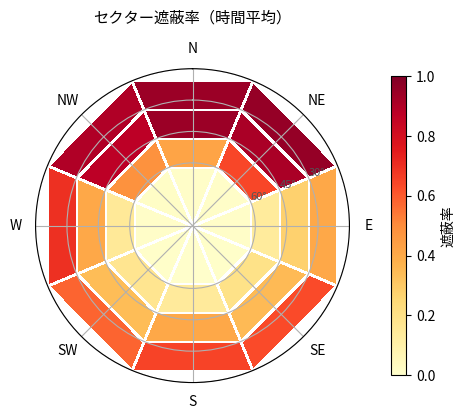

In [17]:
fig = plt.figure(figsize=(5.4, 5.4))
ax = fig.add_subplot(111, projection="polar")
pcm = plot_skygrid(ax, mean_grid(df, meta), meta, "セクター遮蔽率（時間平均）")
fig.colorbar(pcm, ax=ax, shrink=0.72, pad=0.1, label="遮蔽率")
save_fig(fig, "figA_skygrid_mean"); plt.show()

# 任意の1フレームを見る場合:
# k = 50
# fig = plt.figure(figsize=(5.4,5.4)); ax = fig.add_subplot(111, projection="polar")
# plot_skygrid(ax, grid_from_row(df.iloc[k], meta), meta, f"frame {k}"); plt.show()


## ③ Fig B — 仰角バンド別タイムライン

scalar（破線）が、低仰角の高い遮蔽と天頂付近のほぼ0を**平均で潰している**ことを示す。
→ 「方向で分ける」動機の可視化。低仰角バンドがGPS(NLOS/マルチパス)に効くという主張の土台。

saved: /home/ubuntu/ros2_ws/dump/kitakan_0615_1008/analysis/figs_sector/figB_band_timeline.png/.svg


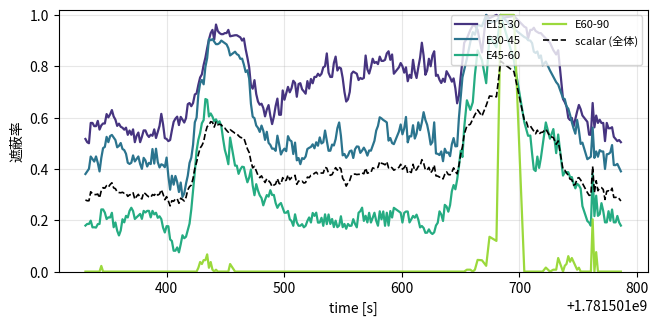

In [18]:
fig, ax = plt.subplots(figsize=(7.6, 3.4))
plot_band_timeline(ax, df, meta)
save_fig(fig, "figB_band_timeline"); plt.show()


## ④ Fig C —【評価1】どの方向・高さの遮蔽が GPS 誤差を説明するか

各セルの遮蔽率と GPS 誤差の相関 r をマップ化。**バンド平均だと方向性が薄まる**ため、
セル単位で見るのが最も診断的。赤＝誤差と正相関（その方向が塞がると誤差増）。

saved: /home/ubuntu/ros2_ws/dump/kitakan_0615_1008/analysis/figs_sector/figC_cell_correlation.png/.svg


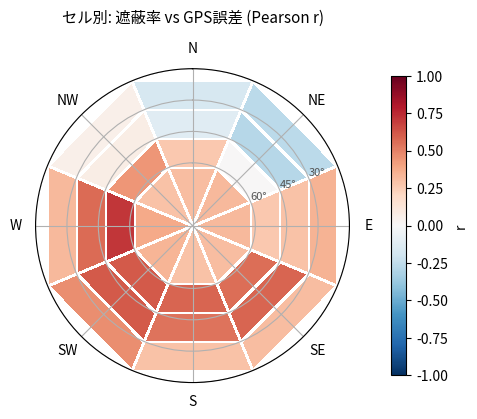

In [19]:
if ERR is not None:
    Rgrid = cell_corr_grid(df, meta, ERR)
    fig = plt.figure(figsize=(5.4, 5.4))
    ax = fig.add_subplot(111, projection="polar")
    pcm = plot_skygrid(ax, Rgrid, meta, "セル別: 遮蔽率 vs GPS誤差 (Pearson r)",
                       cmap="RdBu_r", vmin=-1, vmax=1)
    fig.colorbar(pcm, ax=ax, shrink=0.72, pad=0.1, label="r")
    save_fig(fig, "figC_cell_correlation"); plt.show()
else:
    print("ERR 未設定のためスキップ。①で GPS誤差を結合してください。")


## ⑤ Fig D —【評価2】スカラー vs 方向特徴：相関と重回帰 R²

棒: 各バンド平均と誤差の相関（scalar と比較）。表: 単回帰/重回帰の R²。
**注意**: セル数(=特徴量)がフレーム数に対して多いと R² は過学習で過大評価される。
低仰角の数セクターなど **低次元の方向特徴** で比較するのが誠実。

saved: /home/ubuntu/ros2_ws/dump/kitakan_0615_1008/analysis/figs_sector/figD_corr_compare.png/.svg


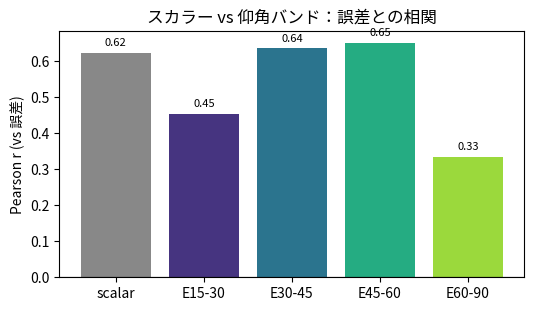

R²  scalar のみ           : 0.388  (n=271)
R²  バンド平均 4特徴量      : 0.453
→ バンド特徴で R² が上がれば「方向分解の価値」を定量化できる（過学習に注意）


In [20]:
if ERR is not None:
    from scipy.stats import pearsonr
    na, nb = meta["n_azimuth"], meta["n_bands"]
    # バンド平均特徴
    feats = {"scalar": df["occ_scalar"].values}
    for b in range(nb):
        cols = [f"occ_e{b}_a{s}" for s in range(na) if f"occ_e{b}_a{s}" in df]
        feats[meta["band_labels"][b]] = df[cols].mean(axis=1, skipna=True).values
    rows = []
    for name, v in feats.items():
        m = np.isfinite(v) & np.isfinite(ERR)
        r = pearsonr(v[m], ERR[m])[0] if (m.sum() > 3 and np.std(v[m]) > 1e-9) else np.nan
        rows.append((name, r))
    # 棒グラフ
    fig, ax = plt.subplots(figsize=(6.0, 3.2))
    names = [r[0] for r in rows]; vals = [r[1] for r in rows]
    cols = ["#888"] + list(matplotlib.colormaps["viridis"](np.linspace(0.15, 0.85, nb)))
    bars = ax.bar(names, vals, color=cols)
    ax.axhline(0, color="k", lw=0.8); ax.set_ylabel("Pearson r (vs 誤差)")
    ax.set_title("スカラー vs 仰角バンド：誤差との相関")
    for b, r in zip(bars, vals):
        if np.isfinite(r):
            ax.text(b.get_x()+b.get_width()/2, r + (0.02 if r >= 0 else -0.05),
                    f"{r:.2f}", ha="center", fontsize=8)
    save_fig(fig, "figD_corr_compare"); plt.show()

    # 重回帰 R²
    y = ERR
    r2_scalar, n1 = ols_r2(df[["occ_scalar"]].values, y)
    band_cols = [c for c in df.columns if c.startswith("occ_e")]
    band_means = np.column_stack(
        [df[[f"occ_e{b}_a{s}" for s in range(na) if f"occ_e{b}_a{s}" in df]]
         .mean(axis=1, skipna=True).values for b in range(nb)])
    r2_bands, _ = ols_r2(band_means, y)
    print(f"R²  scalar のみ           : {r2_scalar:.3f}  (n={n1})")
    print(f"R²  バンド平均 {nb}特徴量      : {r2_bands:.3f}")
    print("→ バンド特徴で R² が上がれば「方向分解の価値」を定量化できる（過学習に注意）")
else:
    print("ERR 未設定のためスキップ。")


## ⑥ R 行列フック — `R_GPS = R₀ · exp(α · occ_dir)`

メイン提案（LiDAR遮蔽率→R行列動的更新）への接続。スカラーではなく **誤差に効く方向の遮蔽**
（例: 低〜中仰角の平均、または Fig C で相関が高いセル）を driver にする。
α, R₀ は下のノブで調整し、Fig C/D の結果から根拠づける。

saved: /home/ubuntu/ros2_ws/dump/kitakan_0615_1008/analysis/figs_sector/figE_R_gps.png/.svg


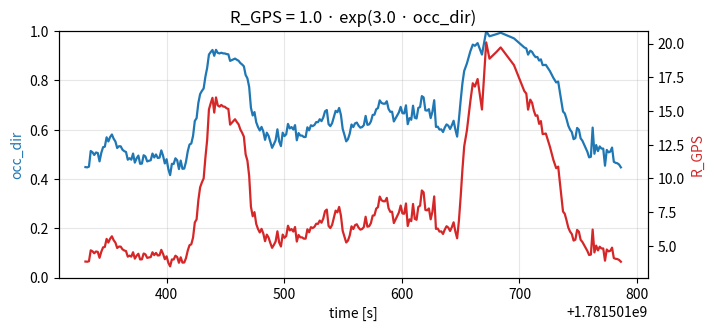

EKF へは、各GPS更新時刻の occ_dir から R_GPS を作って観測ノイズに入れる。


In [21]:
na, nb = meta["n_azimuth"], meta["n_bands"]
R0    = 1.0     # 開空時の GPS 観測分散（要実測キャリブレーション）
ALPHA = 3.0     # 遮蔽感度（Fig C/D の相関から決める）

# driver: 低仰角2バンドの平均（NLOSに効く想定）。Fig C を見て対象セルを変えてよい。
low_bands = [0, 1]
drv_cols = [f"occ_e{b}_a{s}" for b in low_bands for s in range(na)
            if f"occ_e{b}_a{s}" in df]
occ_dir = df[drv_cols].mean(axis=1, skipna=True).values
R_gps = R0 * np.exp(ALPHA * occ_dir)

x = df["t"].values if "t" in df else np.arange(len(df))
fig, ax1 = plt.subplots(figsize=(7.6, 3.2))
ax1.plot(x, occ_dir, color="#1f77b4", lw=1.6, label="occ_dir (低仰角平均)")
ax1.set_xlabel("time [s]"); ax1.set_ylabel("occ_dir", color="#1f77b4")
ax1.set_ylim(0, 1.0); ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(x, R_gps, color="#d62728", lw=1.6, label="R_GPS")
ax2.set_ylabel("R_GPS", color="#d62728")
ax1.set_title(f"R_GPS = {R0} · exp({ALPHA} · occ_dir)")
save_fig(fig, "figE_R_gps"); plt.show()
print("EKF へは、各GPS更新時刻の occ_dir から R_GPS を作って観測ノイズに入れる。")


## 出力ファイル
`figs_sector/` に PNG(220dpi)+SVG で保存:
`figA_skygrid_mean`（遮蔽率マップ）, `figB_band_timeline`（バンド時系列）,
`figC_cell_correlation`（評価:セル別相関）, `figD_corr_compare`（評価:相関比較）,
`figE_R_gps`（R行列）。SVGは白背景=ダークモードでも可読。